# Popularity and tuned ALS: our first recommendation benchmarks

**Checkpoint 2 · models, validation, and honest ranking results**

This notebook answers three questions: how much can popularity alone explain, whether
personalized collaborative filtering improves the ranking, and how the answer changes
when we rank a full catalog instead of a small sampled candidate set.

It loads the completed baseline run, explains the transformations, reproduces its test
metrics, and inspects three users selected without looking at model success. **No model
is trained or tuned by this notebook.** All displayed results and figures are saved.

To reproduce: install `python -m pip install -e ".[baselines,eda]"`, run
`python -m src.baselines --config config/default.yaml`, and select the project's `.venv`
as the notebook kernel. The six original processed files remain unchanged.

Implementation references: [implicit ALS documentation](https://benfred.github.io/implicit/api/models/cpu/als.html)
and [the implicit-feedback formulation](https://yifanhu.net/PUB/cf.pdf). The project
uses raw positive play hours as engagement evidence, not explicit enjoyment ratings.

In [1]:
import json
from dataclasses import asdict
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from threadpoolctl import threadpool_limits

ROOT = next(parent for parent in [Path.cwd(), *Path.cwd().parents]
            if (parent / "src/baselines.py").is_file() and (parent / "config/default.yaml").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.baselines import (
    cases_for, confidence_matrix, input_hashes, load_config, load_dataset,
    load_models, make_identity, popularity_counts, read_interactions, verify_artifacts,
)
from src.evaluate import evaluate_model, metrics_for_rank, rank_games, summarize

config = load_config(ROOT / "config/default.yaml")
assert (config.artifacts_dir / "manifest.json").is_file(), "Run python -m src.baselines first."
original_hashes = input_hashes(config.data.processed_dir)
identity = make_identity(config, original_hashes)
manifest = verify_artifacts(config.artifacts_dir, identity)
dataset = load_dataset(config.data)
popularity, als = load_models(config.artifacts_dir)
metrics = json.loads((config.artifacts_dir / "metrics.json").read_text(encoding="utf-8"))
assert metrics == json.loads((config.results_dir / "metrics.json").read_text(encoding="utf-8"))
train = pd.DataFrame([asdict(row) for row in dataset.train])
test = pd.DataFrame([asdict(row) for row in dataset.test])
games = pd.read_csv(config.data.processed_dir / "games.csv", keep_default_na=False)
display_title = games.set_index("game_id").display_title.to_dict()
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.max_rows", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")
TEAL, SLATE, AMBER = "#087F8C", "#526477", "#D97706"
plt.rcParams.update({
    "figure.figsize": (11, 4.5), "figure.dpi": 120, "font.size": 10,
    "axes.titlesize": 13, "axes.labelsize": 11, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "savefig.bbox": "tight",
})
display(pd.Series({
    "Training interactions": len(train), "Test users": len(test),
    "Persisted game IDs": len(dataset.mapping),
    "Eligible final training games": int((popularity.counts > 0).sum()),
    "Seed": config.data.seed, "Threads": 1, "Numeric dtype": str(als.user_factors.dtype),
    "Dependencies": str(identity["versions"]),
}, name="Verified run").to_frame())

C:\Users\alber\OneDrive\Escritorio\Documentos\UChicago\Projects\AI Steam Recommendation System\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Verified run
Training interactions,55338
Test users,2436
Persisted game IDs,3542
Eligible final training games,3519
Seed,42
Threads,1
Numeric dtype,float32
Dependencies,"{'numpy': '2.2.6', 'scipy': '1.15.3', 'implicit': '0.7.3', 'thread..."


## 1. Add validation without changing the test split

We start from the training history left by the data pipeline and hold out **one more
game per user** using seed 43. A user's original test game is never part of fitting.
The shortest development history has three games: five original games minus one test
and one validation game.

The eight ALS configurations are compared on this validation set. After choosing
the winner, the validation rows return to training and the model is fitted again on
all original training rows. Only then do we evaluate the original test positives.

Other held-out game identities are used solely to exclude known positives from
candidate competitors. Their hours and scores do not enter model fitting or selection.

In [2]:
fit_rows = read_interactions(config.artifacts_dir / "validation_fit.csv", dataset.mapping)
validation_rows = read_interactions(config.artifacts_dir / "validation.csv", dataset.mapping)
development = pd.DataFrame([asdict(row) for row in fit_rows])
validation = pd.DataFrame([asdict(row) for row in validation_rows])
pair_set = lambda rows: {(row.user_id, row.game_title) for row in rows}
assert not pair_set(fit_rows) & pair_set(validation_rows)
assert not (pair_set(fit_rows) | pair_set(validation_rows)) & pair_set(dataset.test)
assert set(fit_rows + validation_rows) == set(dataset.train)
assert development.groupby("user_id").size().min() >= 3
assert validation.groupby("user_id").size().eq(1).all()

display(pd.DataFrame([
    {"Role": "Development fit", "Rows": len(development), "Used for": "Fitting each ALS trial"},
    {"Role": "Validation", "Rows": len(validation), "Used for": "Choosing ALS settings"},
    {"Role": "Final fit (development + validation)", "Rows": len(train), "Used for": "Refitting the chosen model and popularity"},
    {"Role": "Original test", "Rows": len(test), "Used for": "Final comparison only"},
]))

,Role,Rows,Used for
0,Development fit,52902,Fitting each ALS trial
1,Validation,2436,Choosing ALS settings
2,Final fit (development + validation),55338,Refitting the chosen model and popularity
3,Original test,2436,Final comparison only


## 2. Popularity: a useful non-personalized reference

Every distinct training user contributes one play count to a game. The number of
hours does not change this baseline: two users who played for one hour each contribute
more popularity than one user who played for 1,000 hours.

The game scores are the same for every user. Their recommendation lists can still
differ because already-played games are filtered out. We never compute these scores
from test interactions, purchases, or total hours.

In [3]:
expected_popularity = popularity_counts(dataset.train, dataset.mapping)
np.testing.assert_array_equal(popularity.counts, expected_popularity)
top_ids = rank_games(np.flatnonzero(popularity.counts > 0), popularity.counts[popularity.counts > 0])[:12]
display(pd.DataFrame({
    "Game": [display_title[int(game)] for game in top_ids],
    "Distinct training users": popularity.counts[top_ids].astype(int),
}))

,Game,Distinct training users
0,Team Fortress 2,1071
1,Counter-Strike Global Offensive,870
2,Dota 2,853
3,Left 4 Dead 2,629
4,Unturned,606
5,Garry's Mod,556
6,The Elder Scrolls V Skyrim,542
7,Counter-Strike Source,414
8,Portal 2,406
9,Terraria,385


## 3. ALS: preferences and confidence are different quantities

The sparse matrix has **users as rows** and **persisted game IDs as columns**.
A positive observation means preference `p = 1`; its confidence is
`c = 1 + alpha × log(1 + hours)`. Missing interactions are not stored and the solver
treats them as preference zero with confidence one. Missing does not mean the user
explicitly disliked the game.

The logarithm compresses extreme hours, while alpha controls how strongly observed
play should outweigh missing observations. We build confidence explicitly and set
the library's own alpha to **1**, avoiding a second multiplication.

ALS alternates between learning user and game vectors to approximate preferences
under those confidence weights. The recommendation score is a vector dot product;
it is **not predicted hours or a calibrated probability**. Factor dimensions are
learned features, not labeled genres.

,ALS representation
User × game matrix shape,"(2436, 3542)"
Stored positive entries,55338
Density,0.641%
User vector shape,"(2436, 32)"
Game vector shape,"(3542, 32)"
Selected confidence alpha,10
Library alpha,1.000000


,Hours (illustrative),log(1 + hours),"Confidence, alpha=10","Confidence, alpha=40"
0,0.100000,0.095310,1.953102,4.812407
1,1.000000,0.693147,7.931472,28.725887
2,10.000000,2.397895,24.978953,96.915811
3,100.000000,4.615121,47.151205,185.604821
4,"1,000.000000",6.908755,70.087548,277.350191
5,"10,000.000000",9.210440,93.104404,369.417615


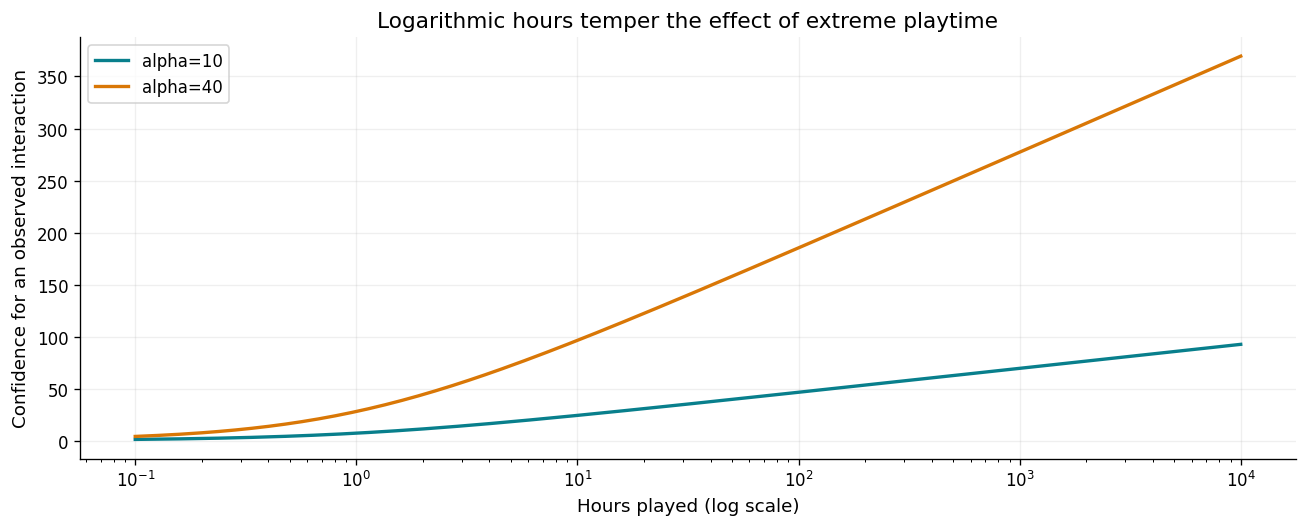

In [4]:
selected = metrics["selected_als"]
matrix = confidence_matrix(dataset.train, dataset.users, dataset.mapping, selected["alpha"])
display(pd.Series({
    "User × game matrix shape": str(matrix.shape),
    "Stored positive entries": matrix.nnz,
    "Density": f"{matrix.nnz / (matrix.shape[0] * matrix.shape[1]):.3%}",
    "User vector shape": str(als.user_factors.shape),
    "Game vector shape": str(als.item_factors.shape),
    "Selected confidence alpha": selected["alpha"],
    "Library alpha": identity["configuration"]["library_alpha"],
}, name="ALS representation").to_frame())

hours = np.array([0.1, 1, 10, 100, 1000, 10000])
display(pd.DataFrame({
    "Hours (illustrative)": hours, "log(1 + hours)": np.log1p(hours),
    "Confidence, alpha=10": 1 + 10 * np.log1p(hours),
    "Confidence, alpha=40": 1 + 40 * np.log1p(hours),
}))
curve_hours = np.geomspace(0.1, 10000, 200)
fig, ax = plt.subplots()
for alpha, color in [(10, TEAL), (40, AMBER)]:
    ax.plot(curve_hours, 1 + alpha * np.log1p(curve_hours), color=color, linewidth=2, label=f"alpha={alpha}")
ax.set(xscale="log", xlabel="Hours played (log scale)", ylabel="Confidence for an observed interaction",
       title="Logarithmic hours temper the effect of extreme playtime")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 4. Select parameters using validation only

The fixed grid contains eight combinations: 32 or 64 factors, regularization 0.01 or
0.1, and confidence alpha 10 or 40. Every trial uses 30 iterations, seed 42, and one
numerical thread. These are a small search, not an exhaustive optimization.

Selection maximizes **full-catalog validation Recall@10 across all users**. MRR breaks
ties; remaining ties retain the first configuration in the fixed grid order. A larger
embedding or confidence weight is not automatically better.

,alpha,factors,grid_order,mrr,recall_at_10,regularization,selected
0,10,32,0,0.162375,0.298440,0.010000,True
1,40,32,1,0.138179,0.271346,0.010000,False
2,10,32,2,0.162120,0.296388,0.100000,False
3,40,32,3,0.140861,0.280378,0.100000,False
4,10,64,4,0.152923,0.270115,0.010000,False
5,40,64,5,0.141662,0.256568,0.010000,False
6,10,64,6,0.155788,0.274631,0.100000,False
7,40,64,7,0.143366,0.257800,0.100000,False


**Selected settings:** {'alpha': 10, 'factors': 32, 'iterations': 30, 'regularization': 0.01}. Test scores did not enter this selection.

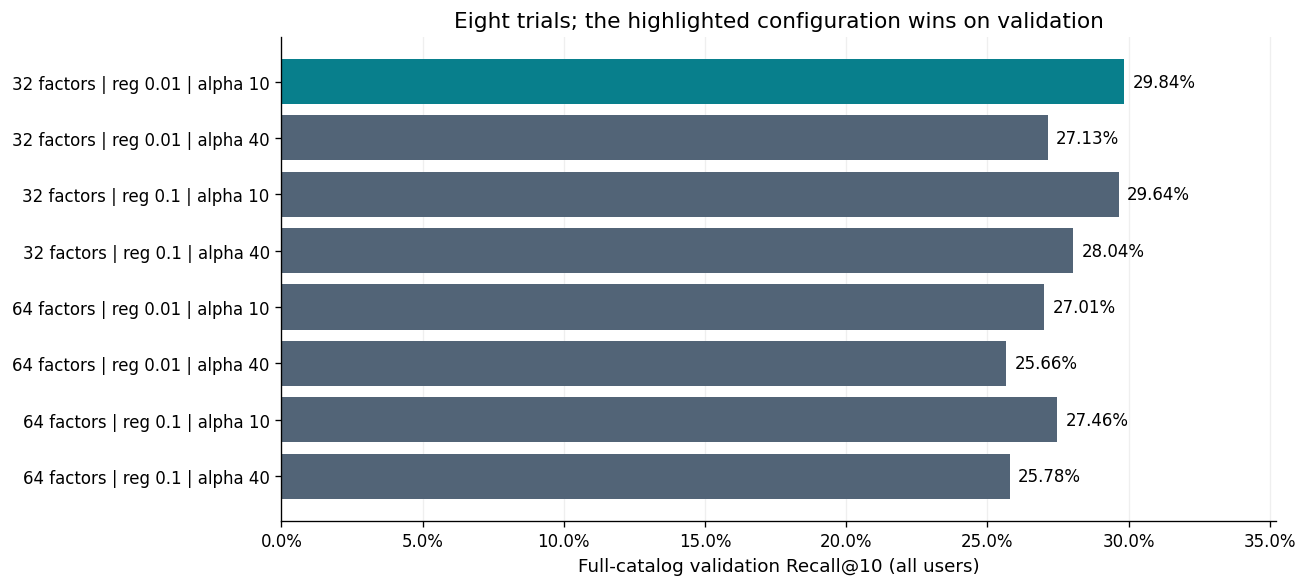

In [5]:
search = pd.DataFrame(metrics["validation_search"])
ordered = search.sort_values(["recall_at_10", "mrr", "grid_order"], ascending=[False, False, True])
assert ordered.iloc[0]["selected"]
assert search.selected.sum() == 1
display(search)
display(Markdown(f"**Selected settings:** {selected}. Test scores did not enter this selection."))

labels = [f"{row.factors} factors | reg {row.regularization:g} | alpha {row.alpha:g}" for row in search.itertuples()]
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(labels, search.recall_at_10, color=[TEAL if chosen else SLATE for chosen in search.selected])
ax.bar_label(bars, labels=[f"{value:.2%}" for value in search.recall_at_10], padding=5)
ax.invert_yaxis()
ax.set(xlabel="Full-catalog validation Recall@10 (all users)", xlim=(0, search.recall_at_10.max() * 1.18),
       title="Eight trials; the highlighted configuration wins on validation")
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

## 5. Fix the candidate sets before comparing models

For full-catalog evaluation, eligible games must have at least one interaction in the
relevant fitting split. For each user, we remove known played games except the target.
For sampled evaluation, we choose up to 100 distinct alternatives with probability
weights proportional to **fitting popularity^0.75**. The target is added only if it has
training support.

These are *unobserved alternatives*, not verified dislikes. The same saved candidates
are shared by both models. A user-specific random stream makes sampling independent
of user iteration order. Higher-popularity games are sampled more often, but less
aggressively than weighting directly by popularity.

Unsupported targets are recorded in the candidate file even though they cannot enter
the eligible ranking. They receive a missing rank and zero metrics, rather than
artificial reciprocal-rank credit for being placed last.

In [6]:
validation_counts = np.load(config.artifacts_dir / "validation_popularity.npy", allow_pickle=False)
np.testing.assert_array_equal(validation_counts, popularity_counts(fit_rows, dataset.mapping))
validation_cases = cases_for(validation_rows, validation_counts, dataset, config, "validation")
test_cases = cases_for(dataset.test, popularity.counts, dataset, config, "test")
for split, cases in [("validation", validation_cases), ("test", test_cases)]:
    with (config.artifacts_dir / f"{split}_candidates.jsonl").open(encoding="utf-8") as handle:
        saved_cases = [json.loads(line) for line in handle]
    assert saved_cases == [case.sampled_record() for case in cases]
    for case in cases:
        assert len(set(case.sampled_ids)) == len(case.sampled_ids)
        assert not (set(case.sampled_ids) - {case.target_game_id}) & dataset.known_positives[case.user_id]

candidate_summary = pd.DataFrame([
    {"Split": split, "Users": len(cases), "Supported targets": sum(case.supported for case in cases),
     "Unsupported targets": sum(not case.supported for case in cases),
     "Min eligible full candidates": min(len(case.full_ids) for case in cases),
     "Max eligible full candidates": max(len(case.full_ids) for case in cases),
     "Sampled alternatives": config.n_negatives}
    for split, cases in [("validation", validation_cases), ("test", test_cases)]
])
display(candidate_summary)

# Same users as the EDA-style examples: histories near 5, 12, and 20 total games.
history_sizes = train.groupby("user_id").size() + 1
example_users = []
for desired_size in [5, 12, 20]:
    distances = (history_sizes - desired_size).abs().sort_values(kind="stable")
    example_users.append(next(user for user in distances.index if user not in example_users))
case_by_user = {case.user_id: case for case in test_cases}
example_case = case_by_user[example_users[0]]
sample_ids = example_case.sampled_ids[:8]
display(pd.DataFrame({
    "Example candidate": [display_title[int(game)] for game in sample_ids],
    "Training play count": popularity.counts[sample_ids],
    "Sampling weight (unnormalized)": popularity.counts[sample_ids] ** config.popularity_exponent,
    "Is test target": sample_ids == example_case.target_game_id,
}))

,Split,Users,Supported targets,Unsupported targets,Min eligible full candidates,Max eligible full candidates,Sampled alternatives
0,validation,2436,2412,24,2999,3492,100
1,test,2436,2411,25,3022,3515,100


,Example candidate,Training play count,Sampling weight (unnormalized),Is test target
0,12 Labours of Hercules II The Cretan Bull,6.000000,3.833659,False
1,3089 -- Futuristic Action RPG,1.000000,1.000000,False
2,aerofly RC 7,1.000000,1.000000,False
3,Alice Madness Returns,26.000000,11.514100,False
4,America's Army Proving Grounds,37.000000,15.002073,False
5,And Yet It Moves,15.000000,7.621991,False
6,APB Reloaded,109.000000,33.734158,False
7,Archeblade,48.000000,18.236057,False


## 6. Recall@10 and MRR measure different things

With one positive per user, Recall@10 is one when its rank is at most ten, and zero
otherwise. MRR averages `1 / rank` over users, rewarding earlier placement throughout
the ranking. **MRR is not truncated at ten.** Both metrics are zero for an unavailable
target. Equal model scores are resolved by ascending game ID for both baselines.

The primary denominator includes every test user. Supported-user metrics answer a
different question: how well does ranking work when the model's eligible catalog
contains the target? We display both and label the population.

In [7]:
display(pd.DataFrame([
    {"Target rank": str(rank) if rank is not None else "Unavailable", "Recall@10": metrics_for_rank(rank)[0],
     "Reciprocal rank": metrics_for_rank(rank)[1]}
    for rank in [1, 2, 10, 11, 100, None]
]))

# Re-score saved final factors, without fitting, and verify every per-user test rank.
replayed = evaluate_model(popularity, test_cases, model_name="popularity", split="test")
replayed += evaluate_model(als, test_cases, model_name="als", split="test")
assert summarize(replayed) == [row for row in metrics["summary"] if row["split"] == "test"]
stored_ranks = pd.read_csv(config.artifacts_dir / "per_user.csv", dtype={"user_id": "string"})
saved_test = stored_ranks.loc[stored_ranks.split.eq("test")].copy()
recomputed = pd.DataFrame(replayed)
sort_keys = ["model", "protocol", "user_id"]
pd.testing.assert_frame_equal(
    saved_test.sort_values(sort_keys).reset_index(drop=True),
    recomputed.sort_values(sort_keys).reset_index(drop=True), check_dtype=False, rtol=1e-12, atol=1e-12,
)
display(Markdown("**Verified:** saved factors reproduce every recorded test rank and aggregate metric."))

,Target rank,Recall@10,Reciprocal rank
0,1,1.000000,1.000000
1,2,1.000000,0.500000
2,10,1.000000,0.100000
3,11,0.000000,0.090909
4,100,0.000000,0.010000
5,Unavailable,0.000000,0.000000


**Verified:** saved factors reproduce every recorded test rank and aggregate metric.

## 7. Compare the final test results

Full-catalog ranking is the headline comparison. The sampled comparison is retained
as planned, but its easier candidate universe must not be confused with catalog-wide
retrieval. A sampled result can be much higher without any improvement to the model.

The table includes all users and the supported subset; the figures emphasize all-user
results. These test results are descriptive findings, not a prompt to tune on test.

,protocol,population,model,n_users,coverage,recall_at_10,mrr
0,full_catalog,all_users,als,2436,0.989737,0.323892,0.174186
1,full_catalog,supported_users,als,2411,0.989737,0.327250,0.175993
2,sampled,all_users,als,2436,0.989737,0.555008,0.299101
3,sampled,supported_users,als,2411,0.989737,0.560763,0.302203
4,full_catalog,all_users,popularity,2436,0.989737,0.220033,0.124391
5,full_catalog,supported_users,popularity,2411,0.989737,0.222314,0.125681
6,sampled,all_users,popularity,2436,0.989737,0.347291,0.181018
7,sampled,supported_users,popularity,2411,0.989737,0.350892,0.182895


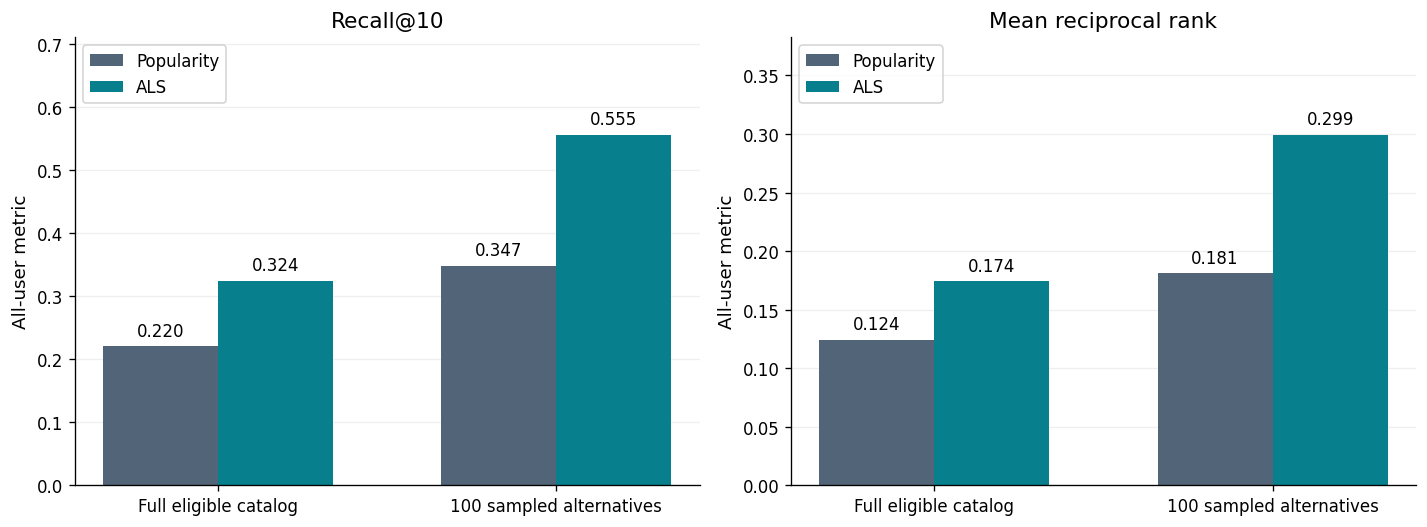

ALS reaches **32.39%** full-catalog Recall@10, versus **22.00%** for popularity: a difference of **+10.39 percentage points**.

In [8]:
summary = pd.DataFrame(metrics["summary"])
test_summary = summary.loc[summary.split.eq("test")].copy()
display(test_summary[["protocol", "population", "model", "n_users", "coverage", "recall_at_10", "mrr"]])
headline = test_summary.loc[test_summary.population.eq("all_users")]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(2)
for ax, metric, title in zip(axes, ["recall_at_10", "mrr"], ["Recall@10", "Mean reciprocal rank"]):
    for index, (model, color) in enumerate([("popularity", SLATE), ("als", TEAL)]):
        values = [headline.loc[headline.model.eq(model) & headline.protocol.eq(protocol), metric].item()
                  for protocol in ["full_catalog", "sampled"]]
        bars = ax.bar(x + (index - 0.5) * 0.34, values, width=0.34, color=color, label=model.upper() if model == "als" else "Popularity")
        ax.bar_label(bars, labels=[f"{value:.3f}" for value in values], padding=4)
    ax.set_xticks(x, ["Full eligible catalog", "100 sampled alternatives"])
    ax.set(title=title, ylim=(0, headline[metric].max() * 1.28), ylabel="All-user metric")
    ax.grid(axis="y", alpha=0.2)
    ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

full = headline.loc[headline.protocol.eq("full_catalog")].set_index("model")
improvement = full.loc["als", "recall_at_10"] - full.loc["popularity", "recall_at_10"]
display(Markdown(
    f"ALS reaches **{full.loc['als', 'recall_at_10']:.2%}** full-catalog Recall@10, versus "
    f"**{full.loc['popularity', 'recall_at_10']:.2%}** for popularity: "
    f"a difference of **{100 * improvement:+.2f} percentage points**."
))

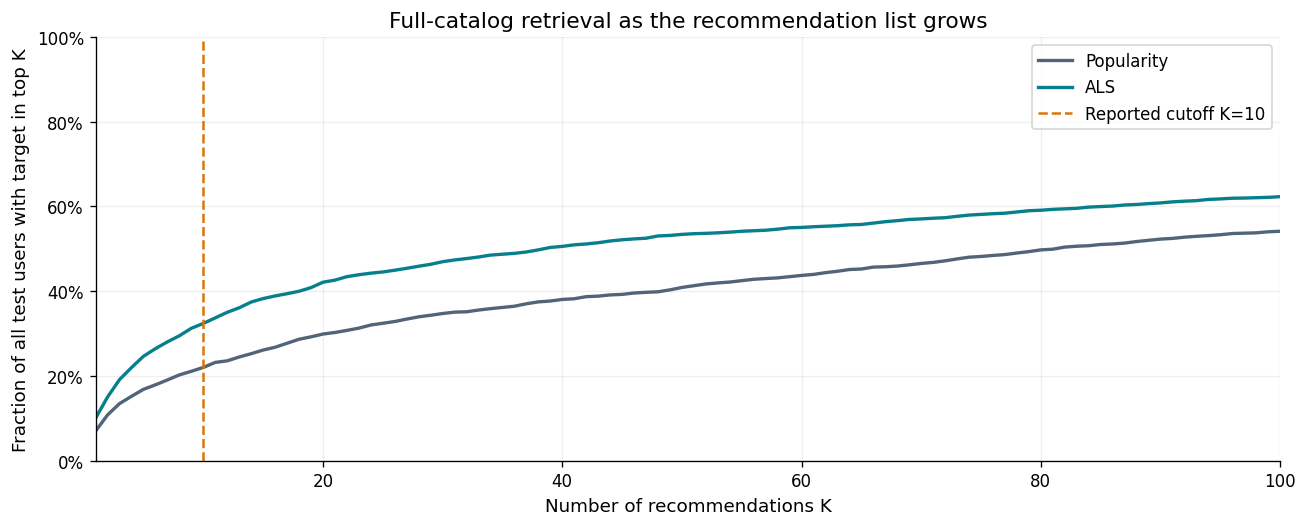

In [9]:
# How often is the positive retrieved as we allow a longer list? Unsupported users remain in the denominator.
ks = np.arange(1, 101)
fig, ax = plt.subplots()
for model, color in [("popularity", SLATE), ("als", TEAL)]:
    rows = saved_test.loc[saved_test.model.eq(model) & saved_test.protocol.eq("full_catalog")]
    recalls = [rows["rank"].le(k).sum() / len(rows) for k in ks]
    ax.plot(ks, recalls, color=color, linewidth=2, label=model.upper() if model == "als" else "Popularity")
ax.axvline(10, color=AMBER, linestyle="--", linewidth=1.5, label="Reported cutoff K=10")
ax.set(xlabel="Number of recommendations K", ylabel="Fraction of all test users with target in top K",
       title="Full-catalog retrieval as the recommendation list grows", xlim=(1, 100), ylim=(0, 1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Inspect three users without cherry-picking successful predictions

We choose users deterministically by histories near 5, 12, and 20 total games, before
looking at their ranks. For each, the first table is the training history. The next
table compares full-catalog ranks, and the final table shows each model's top ten.

Already-played games cannot appear in these recommendation lists. A test target may
appear because it was explicitly withheld from the training history. Scores are only
comparable **within a model**; a popularity count and an ALS dot product use different
scales. The highlighted target column indicates recovery of a known held-out positive,
not proof that every other recommendation is unwanted.

In [10]:
for user_id in example_users:
    history = train.loc[train.user_id.eq(user_id)].sort_values(["hours", "game_title"], ascending=[False, True]).copy()
    history["game_id"] = history.game_title.map(dataset.mapping)
    history["Game"] = history.game_id.map(display_title)
    case = case_by_user[user_id]
    display(Markdown(
        f"### User {user_id}: {len(history)} training games + one test game\n\n"
        f"Held-out target: **{display_title[case.target_game_id]}**. "
        f"Training support: **{'available' if case.supported else 'unavailable'}**."
    ))
    display(history[["Game", "hours"]].rename(columns={"hours": "Training hours"}).reset_index(drop=True))
    user_ranks = saved_test.loc[saved_test.user_id.eq(user_id) & saved_test.protocol.eq("full_catalog")]
    display(user_ranks[["model", "n_candidates", "rank", "recall_at_10", "reciprocal_rank"]].reset_index(drop=True))

    columns = {}
    with threadpool_limits(limits=1):
        for name, model in [("Popularity", popularity), ("ALS", als)]:
            scores = model.score(user_id, case.full_ids)
            ordered = rank_games(case.full_ids, scores)[:10]
            score_by_id = dict(zip(case.full_ids, scores))
            assert not set(ordered) & set(history.game_id)
            columns[f"{name}: game"] = [display_title[int(game)] for game in ordered]
            columns[f"{name}: score"] = [float(score_by_id[game]) for game in ordered]
            columns[f"{name}: target?"] = [bool(game == case.target_game_id) for game in ordered]
    display(pd.DataFrame(columns, index=np.arange(1, len(next(iter(columns.values()))) + 1)).rename_axis("Rank"))

### User 100833937: 4 training games + one test game

Held-out target: **Portal 2**. Training support: **available**.

,Game,Training hours
0,Grand Theft Auto IV,65.000000
1,Cities XL 2012,57.000000
2,Portal,5.900000
3,Puddle,0.400000


,model,n_candidates,rank,recall_at_10,reciprocal_rank
0,als,3515,1.000000,1.000000,1.000000
1,popularity,3515,9.000000,1.000000,0.111111


,Popularity: game,Popularity: score,Popularity: target?,ALS: game,ALS: score,ALS: target?
Rank,,,,,,
1,Team Fortress 2,"1,071.000000",False,Portal 2,0.765779,True
2,Counter-Strike Global Offensive,870.000000,False,Half-Life 2,0.582626,False
3,Dota 2,853.000000,False,Left 4 Dead 2,0.541724,False
4,Left 4 Dead 2,629.000000,False,Left 4 Dead,0.493205,False
5,Unturned,606.000000,False,Grand Theft Auto Episodes from Liberty City,0.475427,False
6,Garry's Mod,556.000000,False,Don't Starve,0.468474,False
7,The Elder Scrolls V Skyrim,542.000000,False,Saints Row The Third,0.467646,False
8,Counter-Strike Source,414.000000,False,L.A. Noire,0.465758,False
9,Portal 2,406.000000,True,XCOM Enemy Unknown,0.444737,False


### User 101212067: 11 training games + one test game

Held-out target: **The Sims(TM) 3**. Training support: **available**.

...

,Popularity: game,Popularity: score,Popularity: target?,ALS: game,ALS: score,ALS: target?
Rank,,,,,,
1,Team Fortress 2,"1,071.000000",False,PAYDAY The Heist,0.963860,False
2,Counter-Strike Global Offensive,870.000000,False,Borderlands 2,0.951418,False
3,Dota 2,853.000000,False,Age of Empires II HD Edition,0.892284,False
4,Left 4 Dead 2,629.000000,False,Portal,0.786232,False
5,Unturned,606.000000,False,BioShock Infinite,0.774468,False
6,Garry's Mod,556.000000,False,Terraria,0.772947,False
7,Counter-Strike Source,414.000000,False,TERA,0.719155,False
8,Terraria,385.000000,False,Left 4 Dead 2,0.708327,False
9,Portal,350.000000,False,Dead Island,0.699964,False


### User 101142088: 19 training games + one test game

Held-out target: **Thief**. Training support: **available**.

,Game,Training hours
0,The Elder Scrolls V Skyrim,252.000000
1,HAWKEN,185.000000
2,ARK Survival Evolved,131.000000
3,Warframe,72.000000
4,Borderlands 2,57.000000
5,Star Conflict,28.000000
6,Neverwinter,24.000000
7,DARK SOULS II Scholar of the First Sin,16.700000
8,Gauntlet,11.600000
9,Nosgoth,11.600000


,model,n_candidates,rank,recall_at_10,reciprocal_rank
0,als,3500,46.000000,0.000000,0.021739
1,popularity,3500,201.000000,0.000000,0.004975


,Popularity: game,Popularity: score,Popularity: target?,ALS: game,ALS: score,ALS: target?
Rank,,,,,,
1,Team Fortress 2,"1,071.000000",False,TERA,1.018792,False
2,Counter-Strike Global Offensive,870.000000,False,Sid Meier's Civilization V,0.986635,False
3,Dota 2,853.000000,False,Magic Duels,0.894773,False
4,Left 4 Dead 2,629.000000,False,Path of Exile,0.851927,False
5,Unturned,606.000000,False,XCOM Enemy Unknown,0.797811,False
6,Garry's Mod,556.000000,False,Tom Clancy's Ghost Recon Phantoms - EU,0.768167,False
7,Counter-Strike Source,414.000000,False,SMITE,0.766835,False
8,Portal 2,406.000000,False,Banished,0.751613,False
9,Terraria,385.000000,False,The Forest,0.745966,False


## 9. Keep catalog coverage visible

Some held-out games have no positive interactions in the fitting data. This checkpoint
does not invent a preference vector or resample those users to improve metrics. Their
targets remain unavailable and contribute zeros to headline results.

The coverage gap and ranking quality are separate findings. Even perfect ranking of
every supported target cannot recover an unavailable target under this eligibility
policy. This is an explicit v1 limitation for ID-based recommendation models.

In [11]:
unsupported = [case for case in test_cases if not case.supported]
coverage = (len(test_cases) - len(unsupported)) / len(test_cases)
display(pd.Series({
    "All test users": len(test_cases), "Supported users": len(test_cases) - len(unsupported),
    "Unsupported users": len(unsupported), "Unsupported distinct games": len({case.target_game_id for case in unsupported}),
    "Target coverage": f"{coverage:.2%}", "Maximum possible all-user Recall@10 under this policy": f"{coverage:.2%}",
}, name="Coverage audit").to_frame())
display(pd.DataFrame([
    {"User": case.user_id, "Unavailable target": display_title[case.target_game_id], "Rank": "Unavailable", "Recall@10": 0, "Reciprocal rank": 0}
    for case in unsupported[:10]
]))
assert saved_test.loc[~saved_test.supported, "rank"].isna().all()
assert saved_test.loc[~saved_test.supported, ["recall_at_10", "reciprocal_rank"]].eq(0).all().all()

,Coverage audit
All test users,2436
Supported users,2411
Unsupported users,25
Unsupported distinct games,23
Target coverage,98.97%
Maximum possible all-user Recall@10 under this policy,98.97%


,User,Unavailable target,Rank,Recall@10,Reciprocal rank
0,100053304,Dream Of Mirror Online,Unavailable,0,0
1,10218563,Flashback,Unavailable,0,0
2,113268833,Fork Parker's Holiday Profit Hike,Unavailable,0,0
3,118541865,Final Slam 2,Unavailable,0,0
4,118693973,Devils Share,Unavailable,0,0
5,118838369,Bard's Gold,Unavailable,0,0
6,125017535,Call of Duty Black Ops - Multiplayer OSX,Unavailable,0,0
7,136791084,Sam & Max 205 What's New Beelzebub?,Unavailable,0,0
8,147602462,Night Mysteries The Amphora Prisoner,Unavailable,0,0
9,150397316,Dream Of Mirror Online,Unavailable,0,0


## 10. What this checkpoint establishes

We now have a reproducible non-personalized baseline, a small validation-tuned
personalized baseline, fixed candidate sets, and a shared evaluator for the later LLM.
The full-catalog comparison is the headline; sampled evaluation is reported separately.

The experiment still uses random holdouts rather than time, historical data, noisy
hours, and a population filtered to users with at least five played games. Neither
offline metric establishes online satisfaction or causal recommendation benefit.

The next checkpoint is the verbalizer and its prompt-leakage tests. There are no LLM
scores to compare yet. Before moving on, inspect the examples above and the saved
comparison report; a baseline losing would also have been a result to report honestly.

In [12]:
assert input_hashes(config.data.processed_dir) == original_hashes
verify_artifacts(config.artifacts_dir, identity)
display(Markdown(
    "**Checkpoint verified:** all six original processed files are unchanged; saved "
    "candidates match their seeded reconstruction; loaded factors reproduce all test "
    "ranks; and aggregate results match the saved report data. "
    "See `results/comparison.md` and `results/metrics.json` for the portable comparison."
))

**Checkpoint verified:** all six original processed files are unchanged; saved candidates match their seeded reconstruction; loaded factors reproduce all test ranks; and aggregate results match the saved report data. See `results/comparison.md` and `results/metrics.json` for the portable comparison.